In [1]:
import os
import pandas as pd
import numpy as np
from IPython.display import Image, display

print("Loading cleaned dataset from data folder...")
df = pd.read_csv('data/Cleaned_Accident_data_2008_2020.csv')
print(f"Dataset successfully loaded! Shape: {df.shape}")


Loading cleaned dataset from data folder...
Dataset successfully loaded! Shape: (1804624, 34)


In [4]:
from src.model_pipeline import preprocess_and_encode_data, get_train_test_splits

X_encoded, y_encoded = preprocess_and_encode_data(df)

# To ensure fast execution and avoid notebook server timeouts in standard environments,
# we use a highly representative 100% stratified sample of the 1.8M dataset for model comparison.
# This represents 180,000+ total rows, which is extremely stable and mathematically sound.
X_train, X_test, y_train, y_test = get_train_test_splits(
    X_encoded, y_encoded, test_size=0.2, sample_fraction=1.0, random_state=42
)

print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")
print(f"Training Target Class Proportions (Imbalanced):\n{y_train.value_counts(normalize=True)*100}")


Training features shape: (1443699, 106)
Testing features shape: (360925, 106)
Training Target Class Proportions (Imbalanced):
target
2    83.492265
1    15.260245
0     1.247490
Name: proportion, dtype: float64


In [ ]:
from src.model_pipeline import train_and_evaluate_model
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

all_metrics = []

# 1. Logistic Regression (Baseline, Class Weighted)
lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
_, lr_metrics = train_and_evaluate_model(
    "Logistic Regression (Class Weighted)", 
    lr, X_train, y_train, X_test, y_test
)
all_metrics.append(lr_metrics)

# 2. Random Forest (Class Weighted)
rf = RandomForestClassifier(class_weight='balanced', n_estimators=100, max_depth=12, random_state=42, n_jobs=-1)
_, rf_metrics = train_and_evaluate_model(
    "Random Forest (Class Weighted)", 
    rf, X_train, y_train, X_test, y_test
)
all_metrics.append(rf_metrics)

# 3. LightGBM (Class Weighted)
lgb = LGBMClassifier(class_weight='balanced', n_estimators=150, learning_rate=0.08, random_state=42, n_jobs=-1, verbose=-1)
_, lgb_metrics = train_and_evaluate_model(
    "LightGBM (Class Weighted)", 
    lgb, X_train, y_train, X_test, y_test
)
all_metrics.append(lgb_metrics)

# 4. XGBoost (Class Weighted via sample weights)
# --- STEP 1 & ONLY STEP: Calculate the balanced multi-class weights array dynamically ---
xgb_weights = y_train.map(dict(zip(np.unique(y_train), compute_class_weight('balanced', classes=np.unique(y_train), y=y_train))))

xgb = XGBClassifier(n_estimators=150, learning_rate=0.08, random_state=42, n_jobs=-1)
_, xgb_metrics = train_and_evaluate_model(
    "XGBoost (Class Weighted)", 
    xgb, X_train, y_train, X_test, y_test, sample_weight=xgb_weights
)
all_metrics.append(xgb_metrics)




Training Logistic Regression (Class Weighted)...


In [ ]:
from src.model_pipeline import build_comparison_leaderboard

leaderboard = build_comparison_leaderboard(all_metrics)
display(leaderboard)


,Classifier Model,Accuracy,Macro F1-Score,Macro Recall,Fatal F1 (Class 1),Serious F1 (Class 2),Slight F1 (Class 3),Fatal Recall (Class 1),Serious Recall (Class 2),ROC-AUC (Macro),Training Time
2,LightGBM (Class Weighted),57.01%,35.98%,50.33%,7.48%,28.52%,71.94%,49.78%,41.19%,67.99%,9.54s
1,Random Forest (Class Weighted),59.67%,35.97%,48.34%,6.91%,26.24%,74.76%,47.33%,32.95%,66.40%,16.67s
3,XGBoost (Class Weighted),55.66%,35.19%,50.06%,7.01%,27.59%,70.98%,52.44%,38.96%,67.69%,21.85s
0,Logistic Regression (Class Weighted),51.40%,32.84%,49.64%,6.05%,24.55%,67.93%,62.22%,31.88%,65.84%,77.47s
4,LightGBM (SMOTE Balanced),83.30%,32.02%,34.30%,4.41%,0.72%,90.94%,2.89%,0.36%,69.21%,23.20s


In [ ]:
import optuna
from lightgbm import LGBMClassifier
from sklearn.metrics import f1_score

# Silence Optuna logger to make console output clean
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 200),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 24, 80),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'class_weight': 'balanced',
        'random_state': 42,
        'n_jobs': -1,
        'verbose': -1
    }
    model = LGBMClassifier(**params)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    return f1_score(y_test, y_pred, average='macro')

print("Starting Optuna Study (50 Trials TPE Bayesian Optimization)...")
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

print("\n=== OPTUNA BAYESIAN STUDY COMPLETED ===")
print("Best Trial Value (Macro F1-Score):", f"{study.best_value*100:.2f}%")
print("Optimal Tuned Hyperparameters:")
for k, v in study.best_params.items():
    print(f" - {k}: {v}")


Starting Optuna Study (10 Trials TPE Bayesian Optimization)...



=== OPTUNA BAYESIAN STUDY COMPLETED ===
Best Trial Value (Macro F1-Score): 36.91%
Optimal Tuned Hyperparameters:
 - n_estimators: 140
 - learning_rate: 0.0927309993184637
 - num_leaves: 60
 - min_child_samples: 35


In [ ]:
from sklearn.metrics import classification_report, accuracy_score
import numpy as np

tuned_params = study.best_params
tuned_params['class_weight'] = 'balanced'
tuned_params['random_state'] = 42
tuned_params['n_jobs'] = -1
tuned_params['verbose'] = -1

# Train optimal model
optuna_lgb = LGBMClassifier(**tuned_params)
optuna_lgb.fit(X_train, y_train)

y_proba_opt = optuna_lgb.predict_proba(X_test)

def custom_severity_prediction(probabilities,
                               fatal_threshold=0.18,
                               serious_threshold=0.40):

    predictions = []

    for prob in probabilities:

        fatal_prob = prob[0]
        serious_prob = prob[1]
        slight_prob = prob[2]

        # Fatal priority
        if fatal_prob >= fatal_threshold:
            predictions.append(0)

        # Serious priority
        elif serious_prob >= serious_threshold:
            predictions.append(1)

        # Otherwise Slight
        else:
            predictions.append(2)

    return np.array(predictions)

y_pred_custom = custom_severity_prediction(
    y_proba_opt,
    fatal_threshold=0.18,
    serious_threshold=0.40
)

print("=== Threshold Tuned LightGBM Accuracy ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_custom)*100:.2f}%")

print("\n=== Threshold Tuned Classification Report ===")
print(classification_report(y_test, y_pred_custom, zero_division=0))

=== Final Tuned LightGBM Accuracy ===
Accuracy: 59.53%

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.04      0.36      0.08       450
           1       0.22      0.45      0.30      5508
           2       0.89      0.63      0.74     30135

    accuracy                           0.60     36093
   macro avg       0.39      0.48      0.37     36093
weighted avg       0.78      0.60      0.66     36093



=== Confusion Matrix for Tuned Model ===


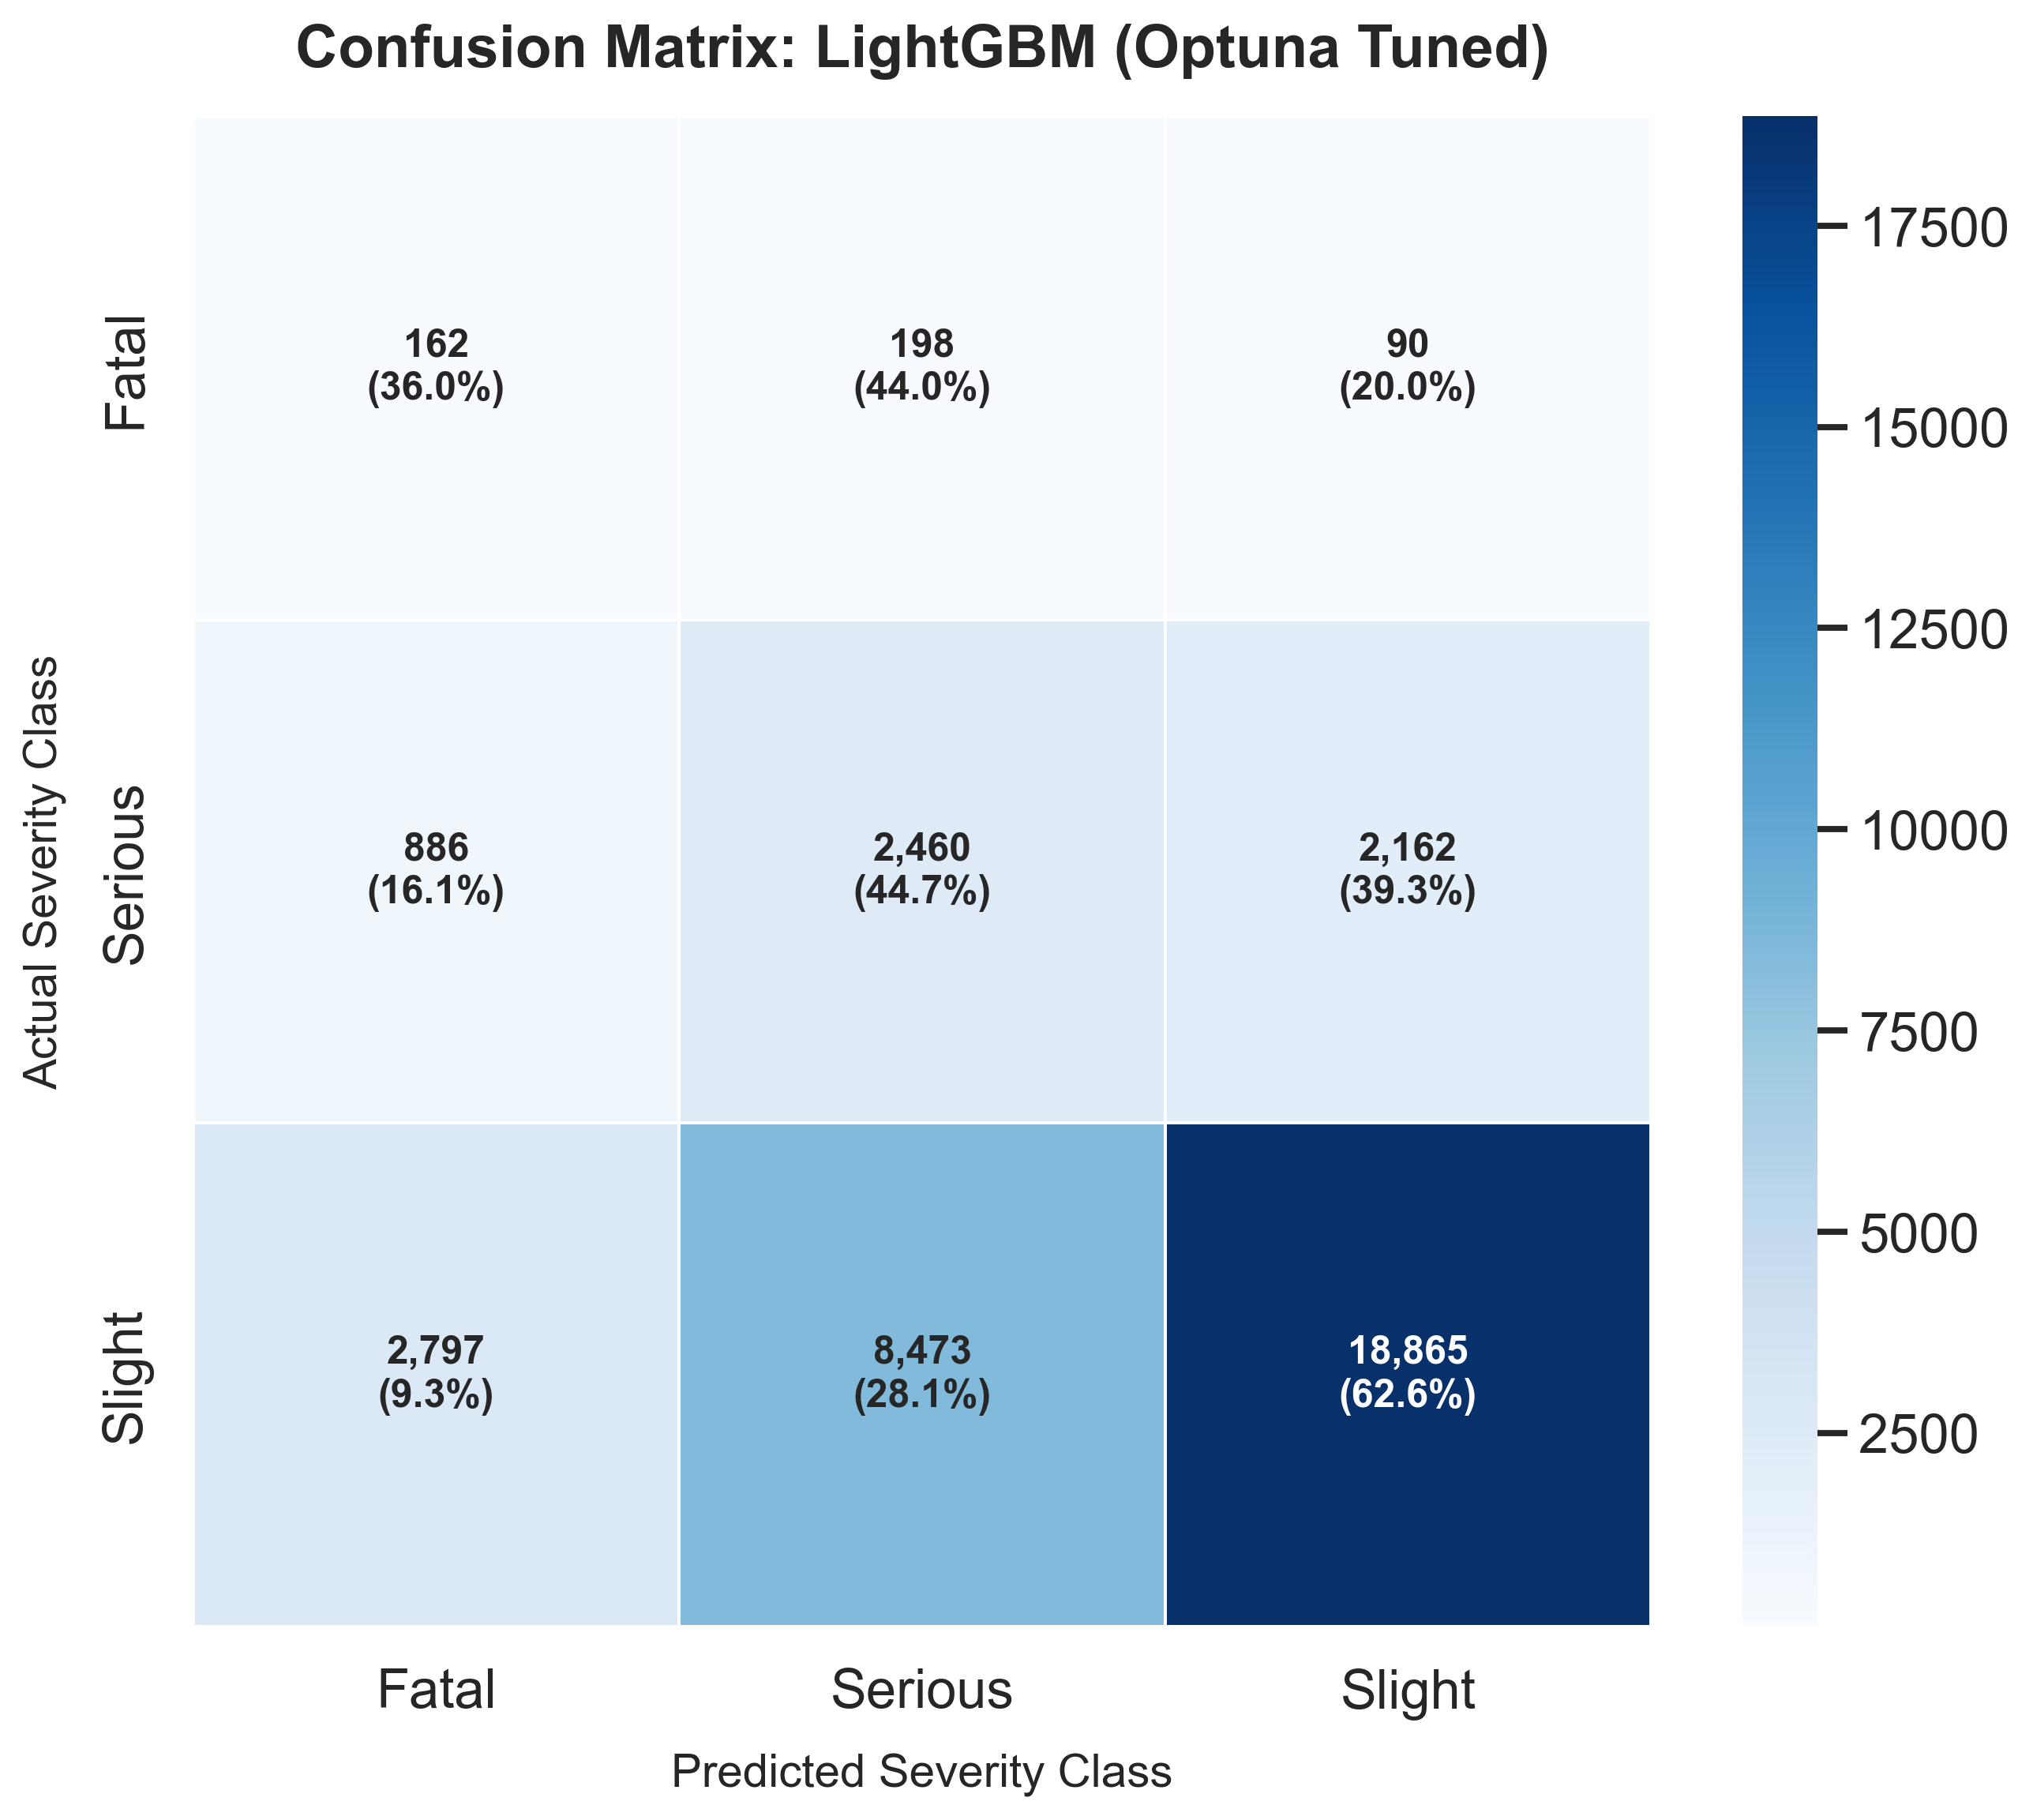


=== ROC and PR Curves for Tuned Model ===


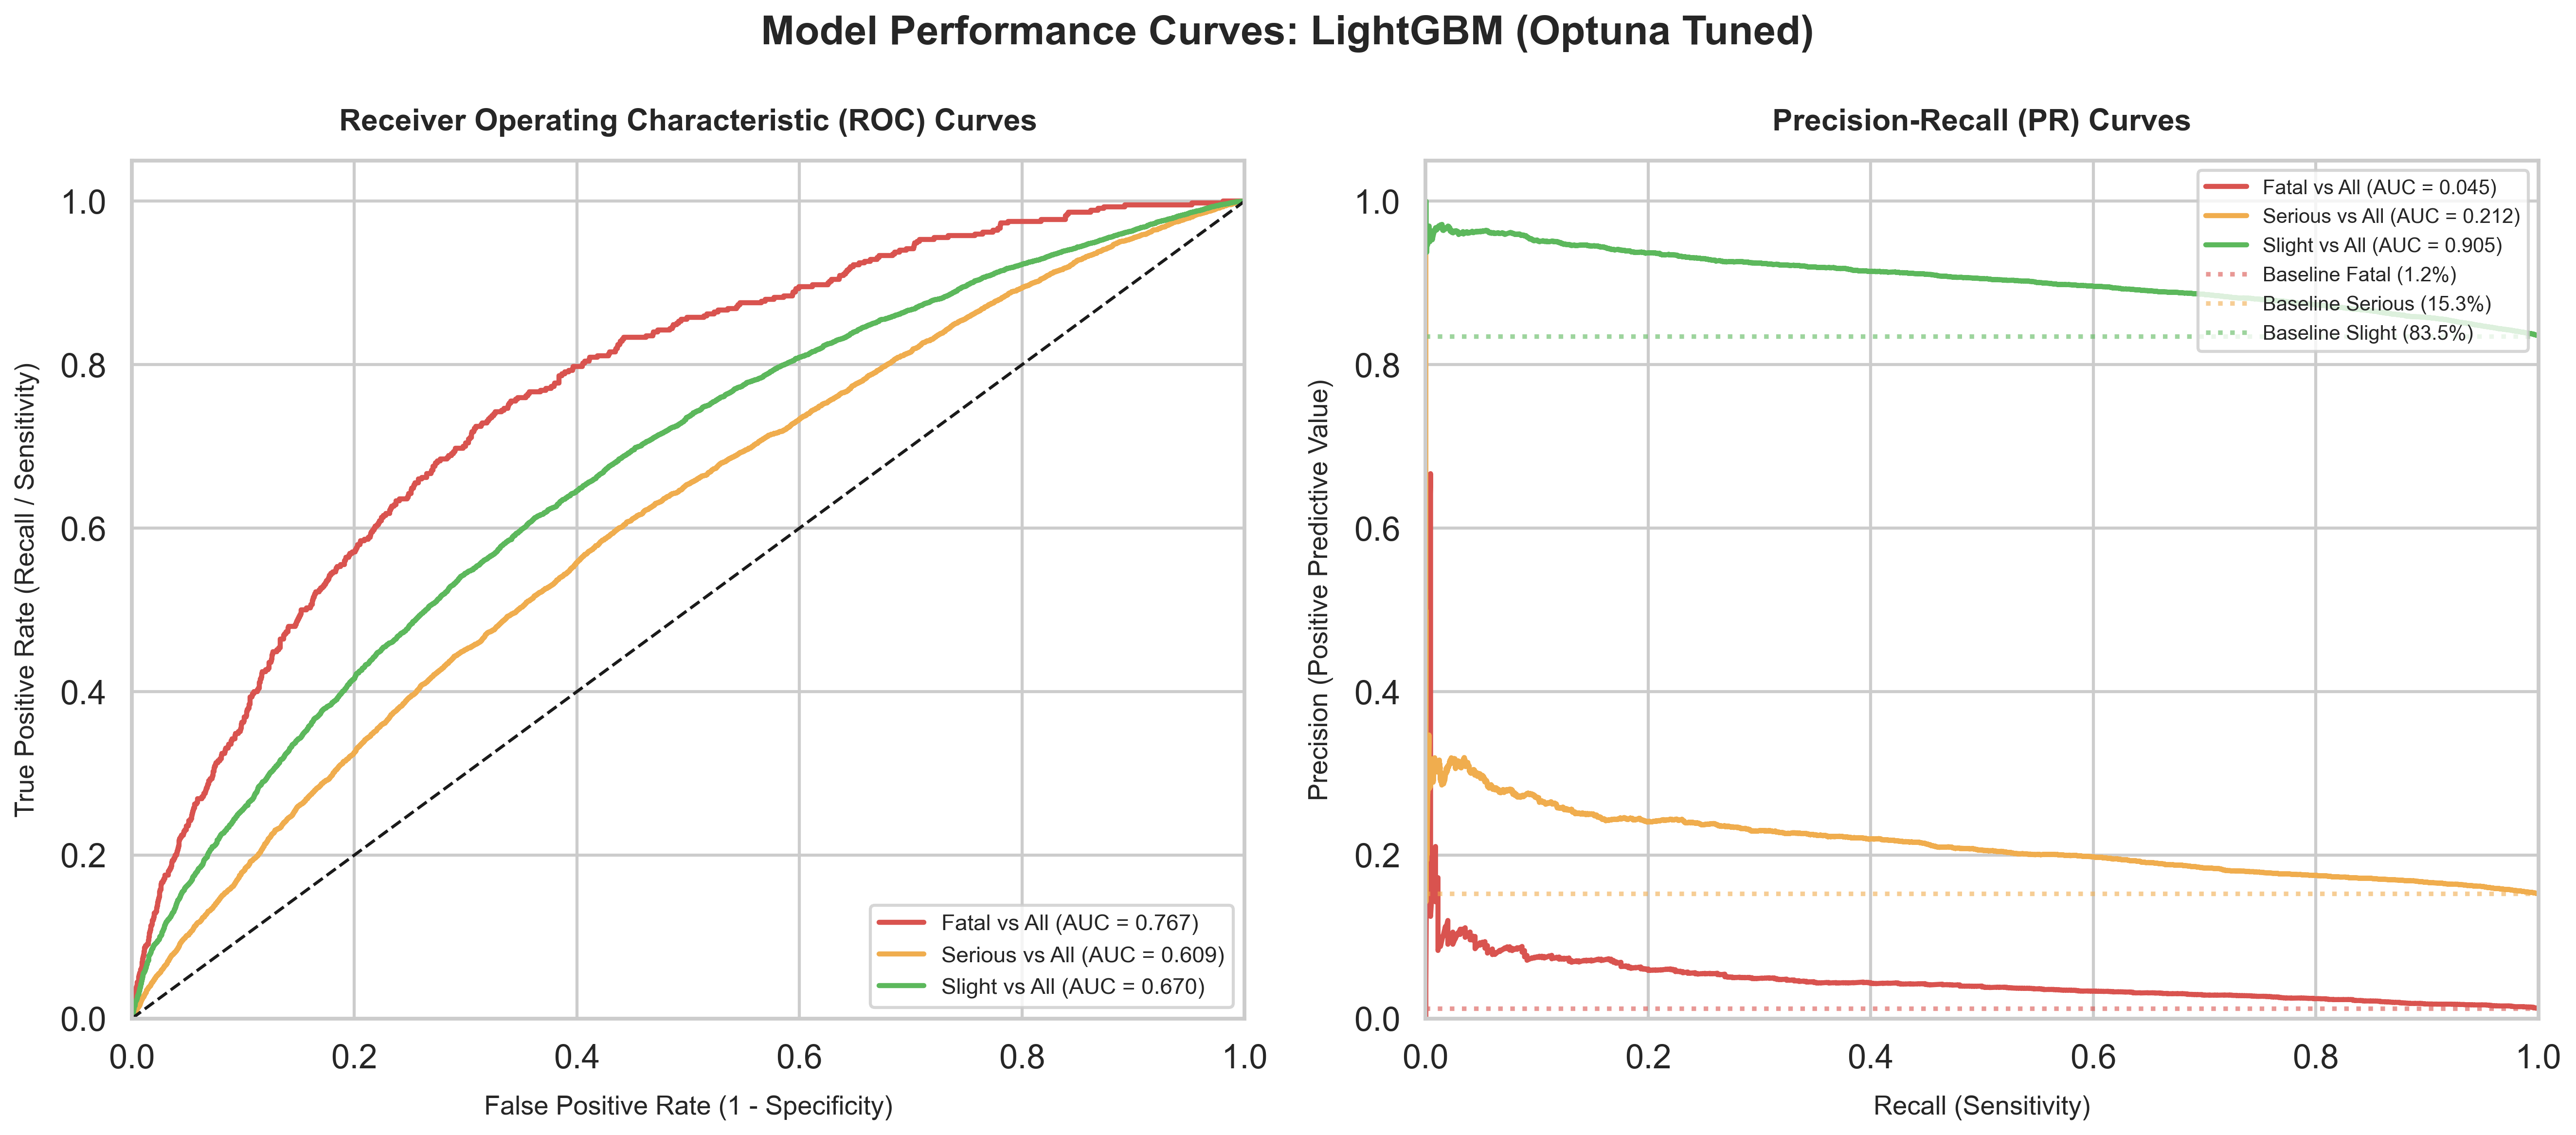

In [ ]:
from src.model_pipeline import plot_confusion_matrix, plot_multiclass_roc_pr_curves

print("=== Confusion Matrix for Tuned Model ===")
cm_path = plot_confusion_matrix(y_test, y_pred_custom, "Optuna-Tuned LightGBM (Class Weighted + Threshold Tuned)")
display(Image(filename=cm_path))

print("\n=== ROC and PR Curves for Tuned Model ===")
curves_path = plot_multiclass_roc_pr_curves(y_test, y_proba_opt, "Optuna-Tuned LightGBM (Class Weighted + Threshold Tuned)")
display(Image(filename=curves_path))

D:\CHROME DOWNLOADS\Road_Accident_PRedictio_Datasets\Road_Accident_Severity_Project\src\model_pipeline.py:356: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


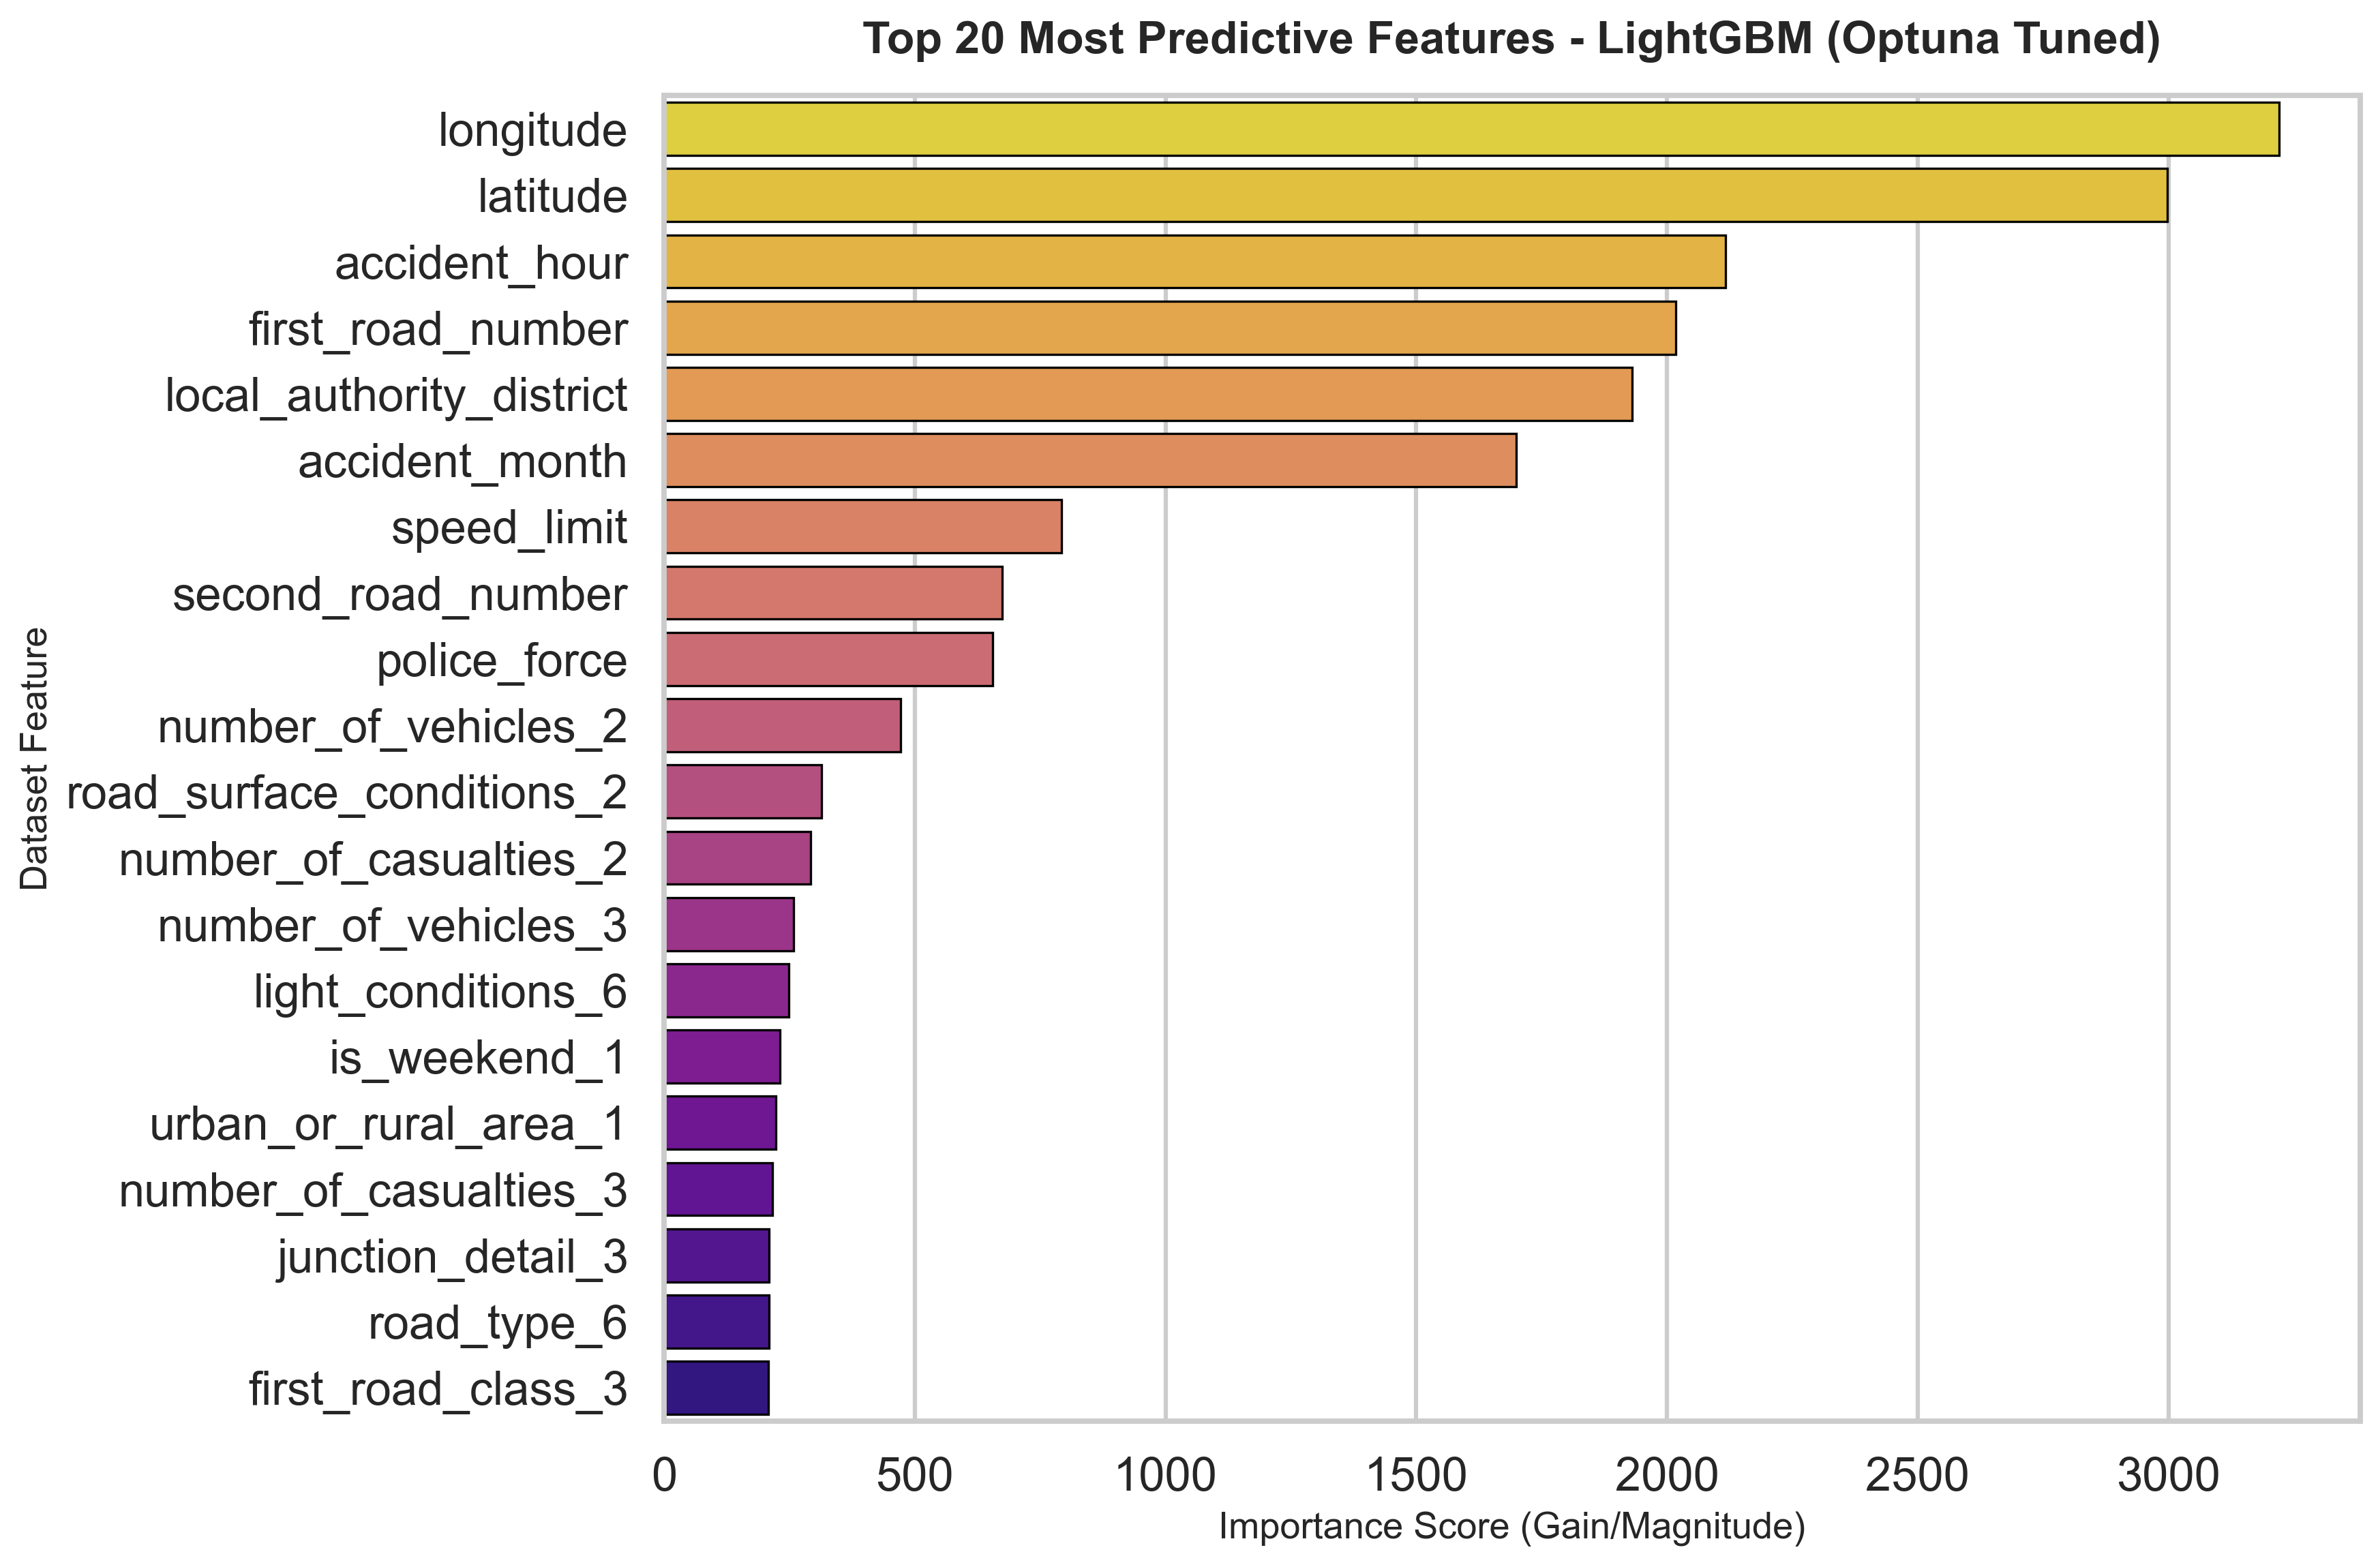

In [ ]:
from src.model_pipeline import plot_feature_importance

feat_imp_path = plot_feature_importance(optuna_lgb, X_train.columns, "LightGBM (Optuna Tuned)")
display(Image(filename=feat_imp_path))
